# Step 1: Load and Prepare datasets

In [1]:
!pip install rdatasets

   ---------------------------------------- 0.0/50.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/50.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/50.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/50.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/50.1 MB ? eta -:--:--
    --------------------------------------- 0.8/50.1 MB 1.5 MB/s eta 0:00:33
    --------------------------------------- 1.0/50.1 MB 1.8 MB/s eta 0:00:28
   - -------------------------------------- 1.6/50.1 MB 1.7 MB/s eta 0:00:28
   -- ------------------------------------- 2.6/50.1 MB 2.4 MB/s eta 0:00:20
   -- ------------------------------------- 3.1/50.1 MB 2.5 MB/s eta 0:00:19
   --- ------------------------------------ 4.5/50.1 MB 3.0 MB/s eta 0:00:16
   ---- ----------------------------------- 5.8/50.1 MB 3.4 MB/s eta 0:00:13
   ----- ---------------------------------- 6.6/50.1 MB 3.5 MB/s eta 0:00:13
   ----- -------------------------

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_wine
from rdatasets import data

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Dataset 1 : Wine
wine_data = load_wine()
wine_df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
wine_df['target'] = wine_data.target

# Dataset 2: Chickwts
chickwts = data('chickwts').dropna()

# Dataset 3: USArrests
usarrests = data('USArrests').dropna()

# Display datasets summary
print("Wine Dataset: \n", wine_df.head(), "\n")
print("Chickwts Dataset: \n", chickwts.head(), "\n")
print("USArrests Dataset: \n", usarrests.head(), "\n")

Wine Dataset: 
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  targ

In [4]:
print("Wine Dataset: \n", wine_df.shape, "\n")
print("Chickwts Dataset: \n", chickwts.shape, "\n")
print("USArrests Dataset: \n", usarrests.shape, "\n")

Wine Dataset: 
 (178, 14) 

Chickwts Dataset: 
 (71, 3) 

USArrests Dataset: 
 (50, 5) 



In [5]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [6]:
wine_df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [7]:
chickwts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  71 non-null     int64 
 1   weight    71 non-null     int64 
 2   feed      71 non-null     object
dtypes: int64(2), object(1)
memory usage: 1.8+ KB


In [8]:
usarrests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [9]:
print("Chickwts Dataset - Null Values: \n", chickwts.isnull().sum())
print("USArrests Dataset - Null Values: \n", usarrests.isnull().sum())

Chickwts Dataset - Null Values: 
 rownames    0
weight      0
feed        0
dtype: int64
USArrests Dataset - Null Values: 
 rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


In [10]:
print("Wine Dataset: \n", wine_df.duplicated().sum(), "\n")
print("Chickwts Dataset: \n", chickwts.duplicated().sum(), "\n")
print("USArrests Dataset: \n", usarrests.duplicated().sum(), "\n")

Wine Dataset: 
 0 

Chickwts Dataset: 
 0 

USArrests Dataset: 
 0 



In [11]:
# standardize numerical features
# Wine dataset
scaler = StandardScaler()
num_cols = wine_df.select_dtypes(include=['float64', 'int64']).columns
wine_df[num_cols] = scaler.fit_transform(wine_df[num_cols])

# Chickwts dataset
scaler = StandardScaler()
num_cols = chickwts.select_dtypes(include=['float64', 'int64']).columns
chickwts[num_cols] = scaler.fit_transform(chickwts[num_cols])

# USArrests dataset
scaler = StandardScaler()
num_cols = usarrests.select_dtypes(include=['float64', 'int64']).columns
usarrests[num_cols] = scaler.fit_transform(usarrests[num_cols])

print(wine_df.describe())
print(chickwts.describe())
print(usarrests.describe())


            alcohol    malic_acid           ash  alcalinity_of_ash  \
count  1.780000e+02  1.780000e+02  1.780000e+02       1.780000e+02   
mean  -8.382808e-16 -1.197544e-16 -8.370333e-16      -3.991813e-17   
std    1.002821e+00  1.002821e+00  1.002821e+00       1.002821e+00   
min   -2.434235e+00 -1.432983e+00 -3.679162e+00      -2.671018e+00   
25%   -7.882448e-01 -6.587486e-01 -5.721225e-01      -6.891372e-01   
50%    6.099988e-02 -4.231120e-01 -2.382132e-02       1.518295e-03   
75%    8.361286e-01  6.697929e-01  6.981085e-01       6.020883e-01   
max    2.259772e+00  3.109192e+00  3.156325e+00       3.154511e+00   

          magnesium  total_phenols    flavanoids  nonflavanoid_phenols  \
count  1.780000e+02     178.000000  1.780000e+02          1.780000e+02   
mean  -3.991813e-17       0.000000 -3.991813e-16          3.592632e-16   
std    1.002821e+00       1.002821  1.002821e+00          1.002821e+00   
min   -2.088255e+00      -2.107246 -1.695971e+00         -1.868234e+00   

# Step 2: k-NN Classification(  wine dataset)

In [12]:
wine_df["target"] = wine_df["target"].astype('int')

# split the datsets into training and testing sets
X =  wine_df.drop(columns=['target'])
y = wine_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA to reduce dimensionality while retaining 95% variance.
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# GridSearchCV to find the optimal k-value and distance metric.
param_grid = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_pca, y_train)

# Best parameters and accuracy
best_params = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']
print(f"Best k-value: {best_params}, Best distance metric: {best_metric}")




Best k-value: 20, Best distance metric: euclidean


In [13]:
# Train the KNN model with the best parameters.
knn = KNeighborsClassifier(n_neighbors=best_params, metric=best_metric)
knn.fit(X_train_pca, y_train)

# predict
y_pred = knn.predict(X_test_pca)
y_pred

print("k-NN classification report:\n", classification_report(y_test, y_pred))
print("K-NN accuracy score: ", accuracy_score(y_test, y_pred))

k-NN classification report:
               precision    recall  f1-score   support

          -1       0.93      1.00      0.97        14
           0       1.00      0.93      0.96        14
           1       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36

K-NN accuracy score:  0.9722222222222222


## Step 3: Recommendation System (Chickwts Dataset)

In [14]:
# Standardize the weight feature.
scaler_weight= StandardScaler()
chickwts_pca = scaler_weight.fit_transform(chickwts[['weight']])

# Apply PCA to reduce data to one principal component.
pca = PCA(n_components=1)
chickwts_pca = pca.fit_transform(chickwts_pca)

# Compute cosine similarity between feed types.
similarity = cosine_similarity(chickwts_pca)

# Recommend similar feeds based on similarity scores.
def recommend_feeds(feed_name, similarity_matrix, top_n=3):
    feed_index = chickwts.index[chickwts['feed'] == feed_name].tolist()[0]
    similarity_scores = list(enumerate(similarity_matrix[feed_index]))
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    
    recommend_feeds = [chickwts.iloc[i[0]]['feed'] for i in similarity_scores[1:top_n+1]]
    return recommend_feeds
print("Recommended feeds for 'casein':", recommend_feeds('casein', similarity, top_n=3))  
print("Recommended feeds for 'horsebean':", recommend_feeds('horsebean', similarity, top_n=3))   


Recommended feeds for 'casein': ['linseed', 'soybean', 'soybean']
Recommended feeds for 'horsebean': ['horsebean', 'horsebean', 'horsebean']


## Step 4: Clustering — K-Means & GMM (USArrests Dataset)

Best number of clusters for K-Means (inertia method): 10
Best number of clusters for GMM: 1


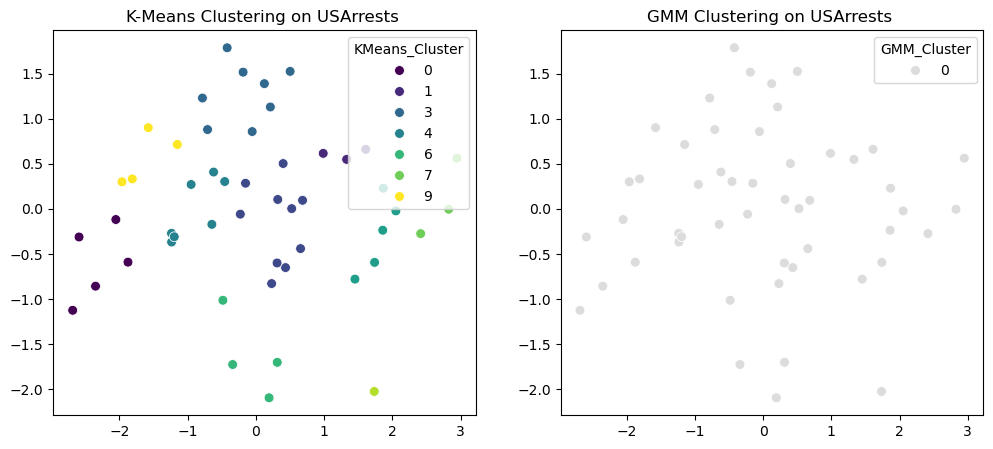

In [15]:
cluster_cols = ["KMeans_Cluster", "GMM_Cluster", "K-means_Cluster"]
usarrests = usarrests.drop(columns=[c for c in cluster_cols if c in usarrests.columns])

# Standardize the dataset.
scaler = StandardScaler()
usarrests_scaled = scaler.fit_transform(usarrests.iloc[:, 1:])

# feature selection : the top 3 relevant features
selector = SelectKBest(score_func=f_classif, k=3)
usarrests_selected = selector.fit_transform(usarrests_scaled, usarrests.index)

#•	Apply PCA to reduce to 2 principal components.
pca = PCA(n_components=2)
usarrests_pca = pca.fit_transform(usarrests_selected)

# Hyperparameter tuning for the optimal number of clusters.
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(usarrests_pca)
    inertia.append(kmeans.inertia_)
    
best_k = inertia.index(min(inertia[1:])) + 1
print(f"Best number of clusters for K-Means (inertia method): {best_k}")

# Apply K-Means clustering
kmeans = KMeans(n_clusters=best_k, random_state=42)
usarrests["KMeans_Cluster"] = kmeans.fit_predict(usarrests_pca)
# BIC for GMM
best_gmm_k = 1
lowest_bic = np.inf
for k in range(1, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(usarrests_pca)
    bic = gmm.bic(usarrests_pca)
    if bic < lowest_bic:
        lowest_bic = bic
        best_gmm_k = k

print(f"Best number of clusters for GMM: {best_gmm_k}")

# Apply GMM clustering
gmm = GaussianMixture(n_components=best_gmm_k, random_state=42)
usarrests["GMM_Cluster"] = gmm.fit_predict(usarrests_pca)

# Visualize and compare clustering results.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=usarrests_pca[:, 0], y=usarrests_pca[:, 1], hue=usarrests["KMeans_Cluster"], palette='viridis', s=50)
plt.title('K-Means Clustering on USArrests ')

plt.subplot(1, 2, 2)
sns.scatterplot(x=usarrests_pca[:, 0], y=usarrests_pca[:, 1], hue=usarrests["GMM_Cluster"], palette='coolwarm', s=50)
plt.title('GMM Clustering on USArrests ')

plt.show()
